In [1]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

# Notebook 5: Propinas como proxy de satisfacción

Se usan las propinas activas y los tickets cerrados. La hora se toma de `Creación`, porque el cierre puede cambiar por ajustes administrativos al final del turno.

In [3]:
df = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
df_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

df['Año'] = 2025
df_26['Año'] = 2026

ventas = pd.concat([df, df_26], ignore_index=True)

ventas['Creación'] = pd.to_datetime(ventas['Creación'])
ventas['Total'] = pd.to_numeric(ventas['Total'], errors='coerce')

ventas = ventas[(ventas['Estado'] == 'Cerrada') & (ventas['Total'] > 0)].copy()

ventas['Fecha'] = ventas['Creación'].dt.normalize()
ventas['Mes'] = ventas['Creación'].dt.month
ventas['Dia'] = ventas['Creación'].dt.day
ventas['Dia_semana'] = ventas['Creación'].dt.dayofweek
ventas['Hora'] = ventas['Creación'].dt.hour

ventas = ventas[['Año', 'Id', 'Fecha', 'Mes', 'Dia', 'Dia_semana', 'Hora', 'Tipo de Venta', 'Total']]

ventas.shape

(12578, 9)

In [4]:
prop_25 = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Propinas')
prop_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Propinas')

prop_25['Año'] = 2025
prop_26['Año'] = 2026

propinas = pd.concat([prop_25, prop_26], ignore_index=True)
propinas = propinas[['Año', 'Id. Venta', 'Valor', 'Cancelada']]

propinas['Valor'] = pd.to_numeric(propinas['Valor'], errors='coerce')
propinas = propinas[propinas['Cancelada'] != 'Sí'].copy()

propinas = propinas.groupby(['Año', 'Id. Venta'], as_index=False)['Valor'].sum()

propinas = propinas.merge(
    ventas,
    left_on=['Año', 'Id. Venta'],
    right_on=['Año', 'Id'],
    how='inner'
)

propinas['Porc'] = propinas['Valor'] / propinas['Total'] * 100

propinas.shape

(3701, 12)

## Porcentaje de propina sobre el ticket

Aquí solo se consideran las ventas que sí tienen una propina activa registrada.

In [5]:
promedio = propinas['Porc'].mean()
mediana = propinas['Porc'].median()

print(f'Promedio general: {promedio:.2f}%')
print(f'Mediana general: {mediana:.2f}%')

resumen_prop = propinas.groupby('Año')['Porc'].agg(['count', 'mean', 'median'])
resumen_prop.columns = ['Propinas', 'Promedio %', 'Mediana %']

display(resumen_prop.round(2))

Promedio general: 9.98%
Mediana general: 10.00%


,Propinas,Promedio %,Mediana %
Año,,,
2025,2298,9.99,10.0
2026,1403,9.97,10.0


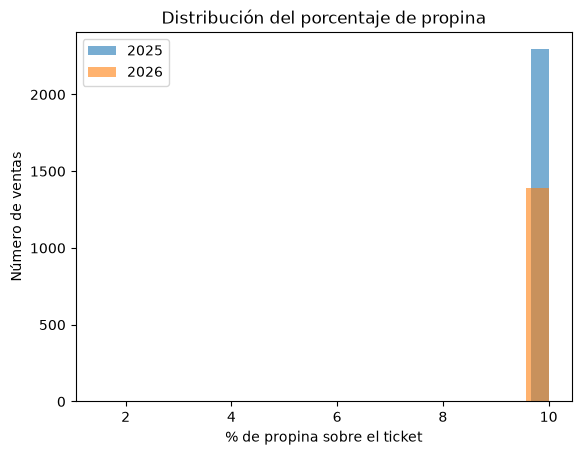

In [6]:
for año in sorted(propinas['Año'].unique()):
    datos = propinas[propinas['Año'] == año]['Porc']
    plt.hist(datos, bins=20, alpha=0.6, label=str(año))

plt.title('Distribución del porcentaje de propina')
plt.xlabel('% de propina sobre el ticket')
plt.ylabel('Número de ventas')
plt.legend()
plt.show()

## Ventas que registran propina

Mostrador se mantiene separado porque una venta para llevar normalmente no tiene el mismo servicio de mesa que una venta Local.

In [7]:
con_propina = ventas.merge(
    propinas[['Año', 'Id. Venta', 'Valor']],
    left_on=['Año', 'Id'],
    right_on=['Año', 'Id. Venta'],
    how='left'
)

con_propina['Tiene_propina'] = con_propina['Valor'].notna()
con_propina['Valor'] = con_propina['Valor'].fillna(0)
con_propina['Porc_venta'] = con_propina['Valor'] / con_propina['Total'] * 100

por_tipo = con_propina.groupby('Tipo de Venta').agg(
    Ventas=('Id', 'size'),
    Con_propina=('Tiene_propina', 'sum')
)

por_tipo['Porc_con_propina'] = por_tipo['Con_propina'] / por_tipo['Ventas'] * 100

display(por_tipo.round(2))

,Ventas,Con_propina,Porc_con_propina
Tipo de Venta,,,
Local,6967,3701,53.12
Mostrador,5611,0,0.00


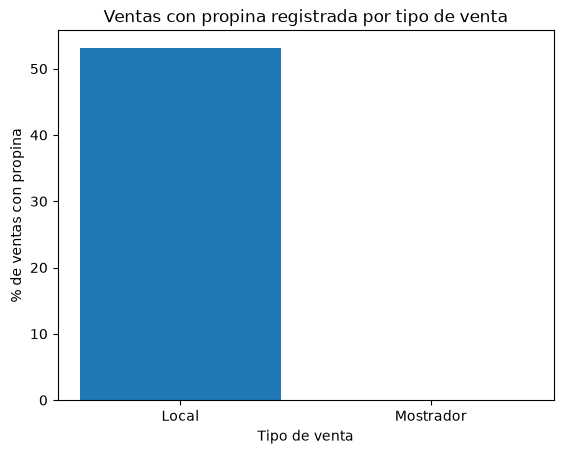

In [8]:
plt.bar(por_tipo.index, por_tipo['Porc_con_propina'])

plt.title('Ventas con propina registrada por tipo de venta')
plt.xlabel('Tipo de venta')
plt.ylabel('% de ventas con propina')
plt.show()

## Propina promedio por hora y día

Para revisar el servicio se usan solo ventas Local. Las ventas sin propina registrada se dejan en 0%: puede ser una propina real de cero, pero también puede ser una propina que no quedó registrada en el sistema, así que esto es una señal aproximada, no una medición exacta de satisfacción.

In [9]:
local = con_propina[con_propina['Tipo de Venta'] == 'Local'].copy()

por_hora = local.groupby('Hora')['Porc_venta'].mean()

display(por_hora.to_frame('Propina promedio %').round(2))

,Propina promedio %
Hora,
7,2.81
8,3.16
9,3.98
10,4.33
11,4.71
12,4.97
13,4.57
14,5.21
15,5.63


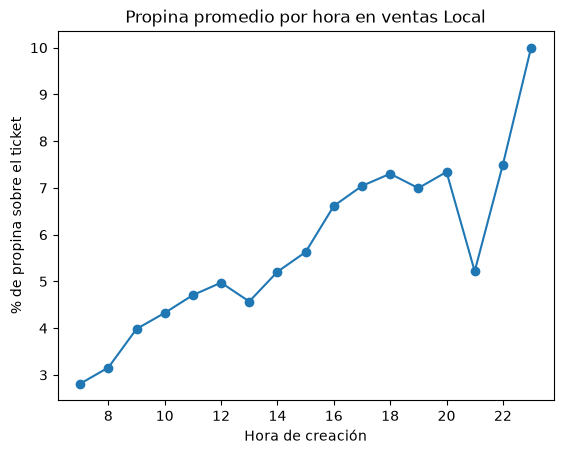

In [10]:
plt.plot(por_hora.index, por_hora.values, marker='o')

plt.title('Propina promedio por hora en ventas Local')
plt.xlabel('Hora de creación')
plt.ylabel('% de propina sobre el ticket')
plt.show()

In [11]:
dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

por_dia_num = local.groupby('Dia_semana')['Porc_venta'].mean().reindex(range(7))
por_dia = por_dia_num.copy()
por_dia.index = dias

display(por_dia.to_frame('Propina promedio %').round(2))

,Propina promedio %
Lunes,4.80
Martes,4.84
Miércoles,4.83
Jueves,4.67
Viernes,5.16
Sábado,6.30
Domingo,6.25


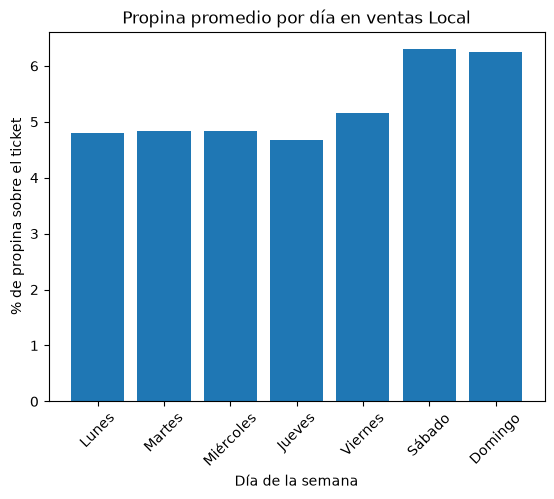

In [12]:
plt.bar(por_dia.index, por_dia.values)

plt.title('Propina promedio por día en ventas Local')
plt.xlabel('Día de la semana')
plt.ylabel('% de propina sobre el ticket')
plt.xticks(rotation=45)
plt.show()

## Comparación 2025 vs 2026

Se comparan los mismos meses disponibles de 2026 contra 2025 para no mezclar el efecto de temporadas que todavía no ocurren en el año actual.

In [13]:
mes_fin = int(local.loc[local['Año'] == 2026, 'Mes'].max()) - 1

comp = local[local['Mes'] <= mes_fin].copy()

por_anio = comp.groupby('Año')['Porc_venta'].mean()

print(f'Comparación de enero a mes {mes_fin}')
display(por_anio.to_frame('Propina promedio %').round(2))

Comparación de enero a mes 9


,Propina promedio %
Año,
2025,6.61
2026,4.97


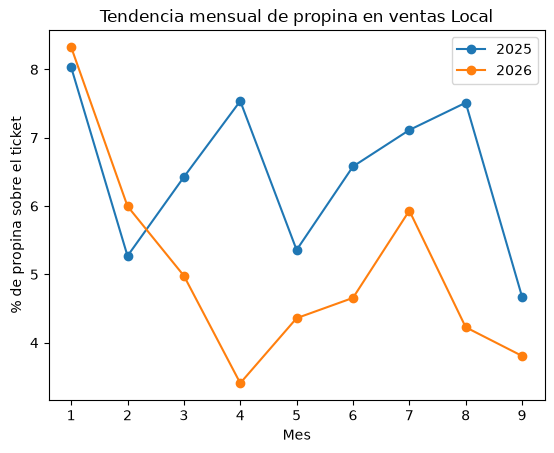

In [14]:
trend = comp.groupby(['Año', 'Mes'])['Porc_venta'].mean().reset_index()

for año in sorted(trend['Año'].unique()):
    datos = trend[trend['Año'] == año]
    plt.plot(datos['Mes'], datos['Porc_venta'], marker='o', label=str(año))

plt.title('Tendencia mensual de propina en ventas Local')
plt.xlabel('Mes')
plt.ylabel('% de propina sobre el ticket')
plt.xticks(range(1, mes_fin + 1))
plt.legend()
plt.show()

In [15]:
hora_baja = por_hora.idxmin()
dia_bajo = por_dia_num.idxmin()

prop_2025 = por_anio.loc[2025]
prop_2026 = por_anio.loc[2026]
cambio = prop_2026 - prop_2025

if cambio < 0:
    lectura = (
        f'El promedio bajó {abs(cambio):.2f} puntos porcentuales en 2026. '
        'Es una señal para revisar si el local más grande después de la mudanza está haciendo más difícil mantener el servicio.'
    )
else:
    lectura = (
        f'El promedio subió {cambio:.2f} puntos porcentuales en 2026. '
        'No aparece una caída general de propina después de la mudanza, aunque las franjas bajas todavía conviene revisarlas.'
    )

display(Markdown(
    f'### Hallazgo principal\n\n'
    f'En ventas Local, la hora con menor propina promedio fue **{hora_baja}:00 h** '
    f'con **{por_hora.loc[hora_baja]:.2f}%**. '
    f'El día más bajo fue **{dias[dia_bajo]}** con **{por_dia_num.loc[dia_bajo]:.2f}%**.\n\n'
    f'De enero a mes {mes_fin}, la propina promedio pasó de **{prop_2025:.2f}%** en 2025 '
    f'a **{prop_2026:.2f}%** en 2026. {lectura}\n\n'
    f'El aumento de precios también puede cambiar el monto de la propina, por eso se compara el porcentaje sobre el ticket y no solo pesos.'
))

### Hallazgo principal

En ventas Local, la hora con menor propina promedio fue **7:00 h** con **2.81%**. El día más bajo fue **Jueves** con **4.67%**.

De enero a mes 9, la propina promedio pasó de **6.61%** en 2025 a **4.97%** en 2026. El promedio bajó 1.64 puntos porcentuales en 2026. Es una señal para revisar si el local más grande después de la mudanza está haciendo más difícil mantener el servicio.

El aumento de precios también puede cambiar el monto de la propina, por eso se compara el porcentaje sobre el ticket y no solo pesos.

## Recomendaciones

Conviene observar de cerca el servicio durante la hora y el día señalados arriba: revisar cobertura de meseros, tiempos de entrega y cuántas mesas atiende cada persona al mismo tiempo.

También conviene revisar este porcentaje cada semana solo para ventas Local, comparándolo contra la misma semana del año anterior. Si la caída se repite varias semanas, se puede ajustar personal o distribución de mesas antes de que afecte la experiencia del cliente.